In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Instagram_Analytics.csv')
df.head()

,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


In [3]:
print(df.shape)
print(df.columns)
df.info()

(29999, 23)
Index(['post_id', 'account_id', 'account_type', 'follower_count', 'media_type',
       'content_category', 'traffic_source', 'has_call_to_action',
       'post_datetime', 'post_date', 'post_hour', 'day_of_week', 'likes',
       'comments', 'shares', 'saves', 'reach', 'impressions',
       'engagement_rate', 'followers_gained', 'caption_length',
       'hashtags_count', 'performance_bucket_label'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   post_id                   29999 non-null  object 
 1   account_id                29999 non-null  int64  
 2   account_type              29999 non-null  object 
 3   follower_count            29999 non-null  int64  
 4   media_type                29999 non-null  object 
 5   content_category          29999 non-null  object 
 6   traffic_sou

In [4]:
df.isnull().sum()

,0
post_id,0
account_id,0
account_type,0
follower_count,0
media_type,0
content_category,0
traffic_source,0
has_call_to_action,0
post_datetime,0
post_date,0


In [5]:
df.describe()

,account_id,follower_count,has_call_to_action,post_hour,likes,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count
count,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,10.567819,10278.305477,0.348778,11.499417,287.653588,8.521917,14.426614,42.517284,6272.475449,8466.952498,0.042107,502.152805,120.081169,7.987933
std,5.763952,6691.862669,0.476592,6.900587,317.647682,10.116505,16.420899,47.808844,4985.877059,6825.900355,0.024095,290.364038,11.009108,2.828130
min,1.000000,3083.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,268.000000,327.000000,0.000000,0.000000,70.000000,0.000000
25%,6.000000,5824.000000,0.000000,6.000000,104.000000,3.000000,5.000000,15.000000,3058.000000,4102.000000,0.024000,251.000000,113.000000,6.000000
50%,11.000000,9044.000000,0.000000,12.000000,199.000000,6.000000,10.000000,29.000000,4913.000000,6595.000000,0.040600,501.000000,120.000000,8.000000
75%,16.000000,10739.000000,1.000000,17.000000,363.000000,11.000000,19.000000,54.000000,7863.000000,10620.500000,0.057000,755.000000,127.000000,10.000000
max,20.000000,31095.000000,1.000000,23.000000,10632.000000,339.000000,516.000000,1542.000000,73339.000000,105203.000000,0.271000,1000.000000,166.000000,21.000000


In [6]:
print(df.columns)

Index(['post_id', 'account_id', 'account_type', 'follower_count', 'media_type',
       'content_category', 'traffic_source', 'has_call_to_action',
       'post_datetime', 'post_date', 'post_hour', 'day_of_week', 'likes',
       'comments', 'shares', 'saves', 'reach', 'impressions',
       'engagement_rate', 'followers_gained', 'caption_length',
       'hashtags_count', 'performance_bucket_label'],
      dtype='object')


In [7]:
df['post_datetime'] = pd.to_datetime(df['post_datetime'])

df[['post_datetime']].head()

,post_datetime
0,2024-11-30 06:00:00
1,2025-08-15 15:00:00
2,2025-09-11 16:00:00
3,2025-09-18 03:00:00
4,2025-03-21 09:00:00


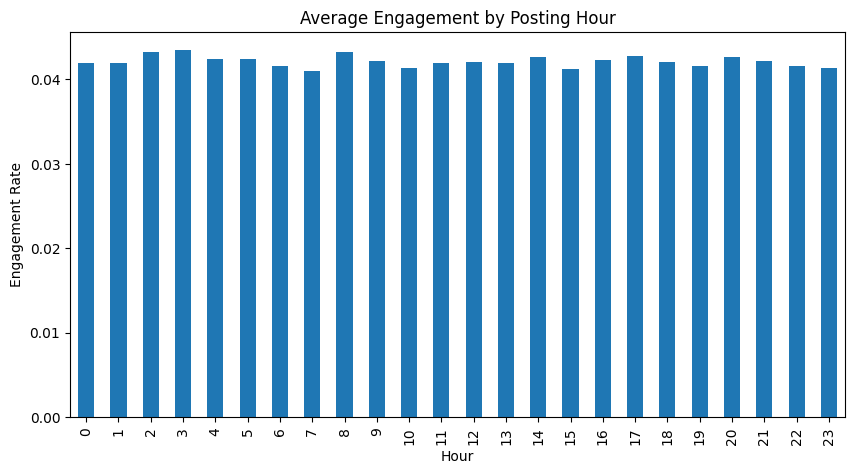

In [8]:
plt.figure(figsize=(10,5))

hourly_engagement = df.groupby('post_hour')['engagement_rate'].mean()

hourly_engagement.plot(kind='bar')

plt.title("Average Engagement by Posting Hour")
plt.xlabel("Hour")
plt.ylabel("Engagement Rate")

plt.show()

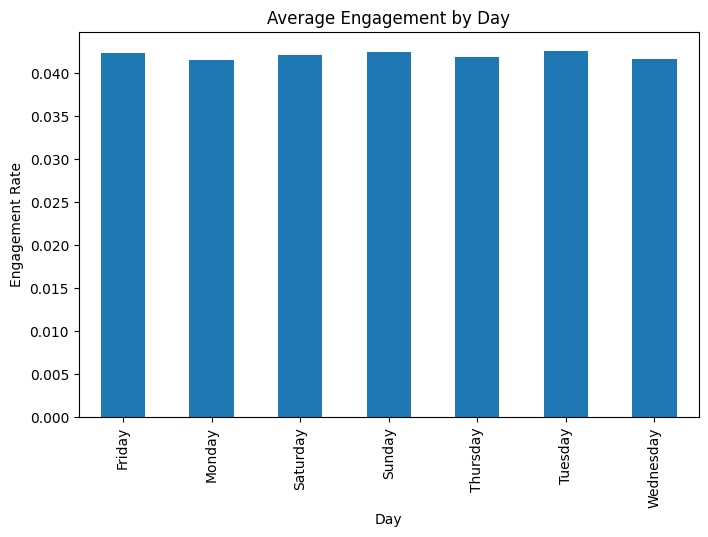

In [9]:
plt.figure(figsize=(8,5))

day_engagement = df.groupby('day_of_week')['engagement_rate'].mean()

day_engagement.plot(kind='bar')

plt.title("Average Engagement by Day")
plt.xlabel("Day")
plt.ylabel("Engagement Rate")

plt.show()

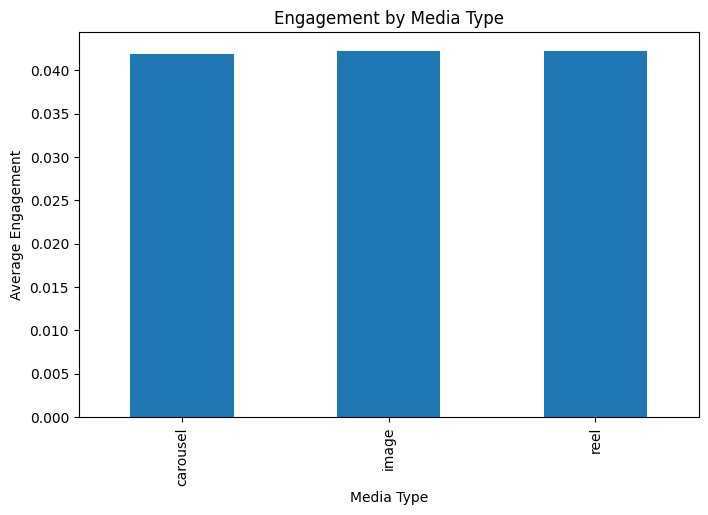

In [10]:
plt.figure(figsize=(8,5))

content_engagement = df.groupby('media_type')['engagement_rate'].mean()

content_engagement.plot(kind='bar')

plt.title("Engagement by Media Type")
plt.xlabel("Media Type")
plt.ylabel("Average Engagement")

plt.show()

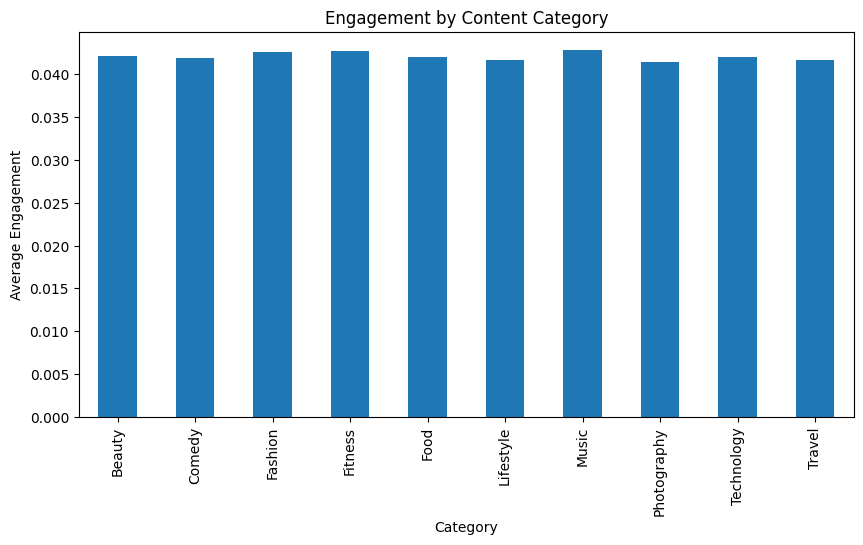

In [11]:
plt.figure(figsize=(10,5))

category_engagement = df.groupby('content_category')['engagement_rate'].mean()

category_engagement.plot(kind='bar')

plt.title("Engagement by Content Category")
plt.xlabel("Category")
plt.ylabel("Average Engagement")

plt.show()

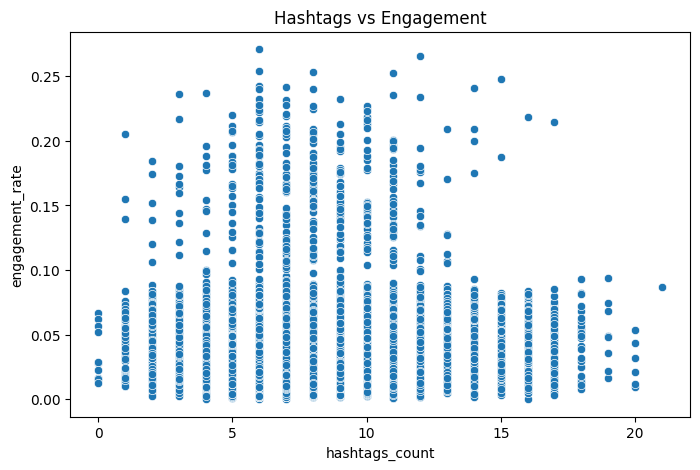

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='hashtags_count',
    y='engagement_rate'
)

plt.title("Hashtags vs Engagement")

plt.show()

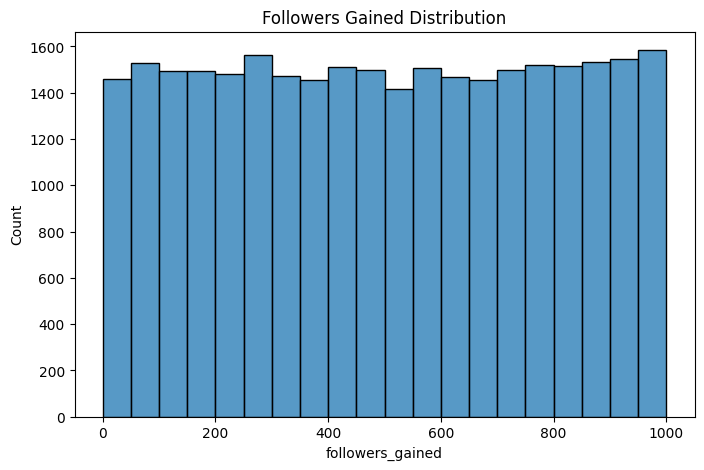

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['followers_gained'], bins=20)

plt.title("Followers Gained Distribution")

plt.show()

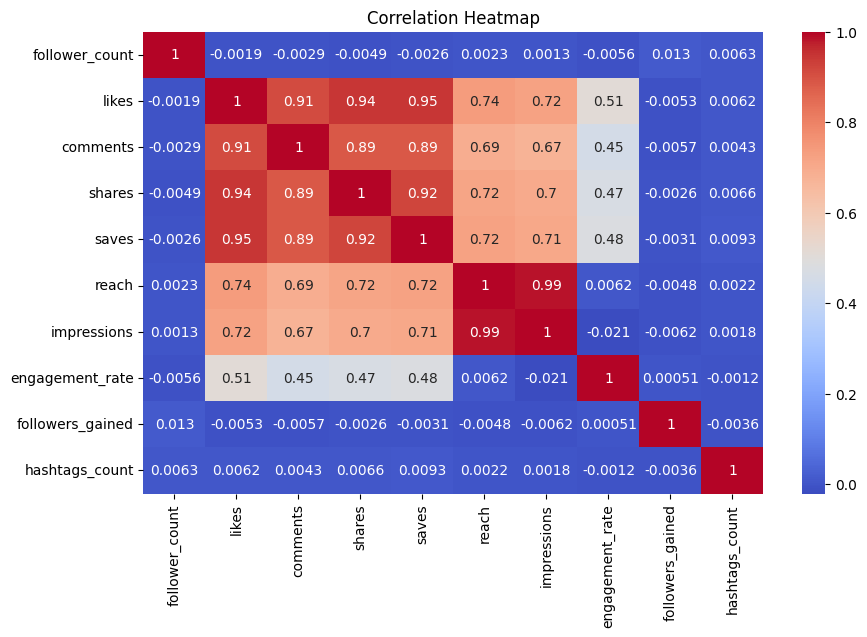

In [14]:
numeric_cols = [
    'follower_count',
    'likes',
    'comments',
    'shares',
    'saves',
    'reach',
    'impressions',
    'engagement_rate',
    'followers_gained',
    'hashtags_count'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [15]:
top_content = df.groupby('media_type')['engagement_rate'].mean()

print(top_content.sort_values(ascending=False))

media_type
reel        0.042266
image       0.042256
carousel    0.041829
Name: engagement_rate, dtype: float64


In [16]:
best_hour = df.groupby('post_hour')['engagement_rate'].mean().idxmax()

print("Best Posting Hour:", best_hour)

Best Posting Hour: 3


In [17]:
best_day = df.groupby('day_of_week')['engagement_rate'].mean().idxmax()

print("Best Posting Day:", best_day)

Best Posting Day: Tuesday


In [18]:
df.to_csv(
    'instagram_analysis_cleaned.csv',
    index=False
)

print("Dataset saved successfully")

Dataset saved successfully
